# **03 LangGraph 기본 사용법 - 메시지 상태 업데이트**

### 학습 내용
1. LangGraph의 State 개념 이해
2. 메시지 기반 상태 업데이트
3. add_messages 리듀서 활용
4. invoke/stream/astream 비교 및 사용법
5. 스트림 모드별 차이점 이해

## 1. 환경 설정

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


## 2. 챗봇 메시지 상태 관리


In [8]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from typing_extensions import TypedDict

# State 정의
class State(TypedDict):
    messages: list[AnyMessage]
    extra_field: int

In [9]:
# 노드 정의 - 메시지를 수동으로 누적
def node(state: State):
    messages = state["messages"]
    new_message = AIMessage("안녕하세요! 무엇을 도와드릴까요?")

    return {"messages": messages + [new_message], "extra_field": 10}

In [10]:
from langgraph.graph import StateGraph

# 그래프 빌더 생성
graph_builder = StateGraph(State)
graph_builder.add_node("node", node)
graph_builder.set_entry_point("node")  # 시작 노드 지정
graph = graph_builder.compile()

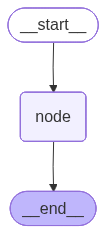

In [11]:
# 그래프 시각화
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [12]:
# 그래프 실행
result = graph.invoke({"messages": [HumanMessage("안녕")]})
print("\n실행 결과:")
print(result)


실행 결과:
{'messages': [HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}), AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'extra_field': 10}


In [13]:
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

안녕
================================== Ai Message ==================================

안녕하세요! 무엇을 도와드릴까요?


## 3. add_messages 리듀서로 자동 누적

`add_messages`는 메시지를 자동으로 누적하는 **리듀서(reducer)** 함수입니다.

https://reference.langchain.com/python/langgraph/graph/message/add_messages


- 메시지 자동 병합
- 중복 메시지 ID 처리
- 코드 간소화
- 메시지 수정 및 삭제 지원

### 3-1. add_messages 기본 사용법

In [14]:
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph.message import add_messages

msgs1 = [HumanMessage(content="Hello", id="1")]
msgs2 = [AIMessage(content="Hi there!", id="2")]
add_messages(msgs1, msgs2)

[HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='1'),
 AIMessage(content='Hi there!', additional_kwargs={}, response_metadata={}, id='2', tool_calls=[], invalid_tool_calls=[])]

In [15]:
# 동일 ID로 메시지 업데이트
msgs1 = [HumanMessage(content="첫 번째 메시지", id="1")]
msgs2 = [HumanMessage(content="수정된 메시지", id="1")]  # 동일 ID

result = add_messages(msgs1, msgs2)

print("\nID가 같은 경우 (메시지 수정):")
for msg in result:
    print(f"{type(msg).__name__} (id={msg.id}): {msg.content}")


ID가 같은 경우 (메시지 수정):
HumanMessage (id=1): 수정된 메시지


### 3-2. add_messages 를 리듀서로 사용하기

In [16]:
from typing_extensions import Annotated
from langgraph.graph.message import add_messages

# State 정의 - Annotated로 add_messages 리듀서 지정
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    extra_field: int

In [17]:
def node(state: State):
    new_message = AIMessage("안녕하세요! 무엇을 도와드릴까요?")

    # 새 메시지만 반환 (add_messages가 자동으로 누적)
    return {"messages": new_message, "extra_field": 10}

In [18]:
graph_builder = StateGraph(State)
graph_builder.add_node("node", node)
graph_builder.set_entry_point("node")
graph = graph_builder.compile()

In [19]:
# 그래프 실행
input_message = {"role": "user", "content": "안녕하세요."}
result = graph.invoke({"messages": [input_message]})

print("\n메시지 출력:")
for message in result["messages"]:
    message.pretty_print()


메시지 출력:
================================ Human Message =================================

안녕하세요.
================================== Ai Message ==================================

안녕하세요! 무엇을 도와드릴까요?


In [20]:
# 상태 확인
print("\n전체 상태:")
print(f"extra_field: {result['extra_field']}")
print(f"메시지 개수: {len(result['messages'])}")


전체 상태:
extra_field: 10
메시지 개수: 2


### 📖 과제 1: 카운터 상태 관리

다음 요구사항을 만족하는 그래프를 만들어보세요:

**요구사항**:
1. State에 `messages`와 `counter` 필드 정의
2. `counter`는 메시지가 추가될 때마다 1씩 증가
3. 노드에서 메시지와 함께 counter를 업데이트
4. 최종 counter 값 출력

**힌트**: 
- `messages`는 `Annotated[list[AnyMessage], add_messages]`
- `counter`는 `int` 타입으로 정의하고 수동으로 증가

**예상 출력**:
```python
# 메시지 개수: 2
# counter: 2
```

In [ ]:
# CODE HERE

<details>

<summary>모범 답안 펼쳐보기</summary>

```python
from typing_extensions import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph

# State 정의
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    counter: int

# 노드 정의
def node(state: State):
    # 현재 counter 값 가져오기
    current_counter = state.get("counter", 0)

    # 새 메시지 생성
    new_message = AIMessage("안녕하세요! 무엇을 도와드릴까요?")

    # counter를 1 증가시켜 반환
    return {"messages": new_message, "counter": current_counter + 1}

# 그래프 구성
graph_builder = StateGraph(State)
graph_builder.add_node("node", node)
graph_builder.set_entry_point("node")
graph = graph_builder.compile()

# 실행
result = graph.invoke({"messages": [HumanMessage("안녕하세요.")], "counter": 1})

# 결과 출력
print(f"메시지 개수: {len(result['messages'])}")
print(f"counter: {result['counter']}")

# 메시지 출력
print("\n메시지 내용:")
for msg in result["messages"]:
    msg.pretty_print()
```

</details>

## 4. LLM 연결하여 대화형 챗봇 그래프 만들기

In [23]:
from typing_extensions import Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    "gpt-4o-mini"
)

# State 정의
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# 챗봇 노드
def chatbot(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": response}

# 그래프 구성
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.set_entry_point("chatbot")
graph = graph_builder.compile()

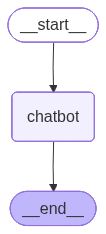

In [24]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

## 6. invoke - 일반 호출

In [25]:
# invoke - 동기 방식
user_message = HumanMessage("Python의 장점을 3가지만 알려주세요.")
result = graph.invoke({"messages": [user_message]})

print("\n[invoke 결과]")
for msg in result["messages"]:
    msg.pretty_print()


[invoke 결과]
================================ Human Message =================================

Python의 장점을 3가지만 알려주세요.
================================== Ai Message ==================================

파이썬의 장점은 여러 가지가 있지만, 그 중에서도 특히 두드러진 세 가지를 소개하겠습니다:

1. **단순하고 읽기 쉬운 문법**: 파이썬은 코드의 가독성을 중요하게 생각하여 설계되었습니다. 따라서 다른 프로그래밍 언어에 비해 훨씬 더 간결하고 쉽게 작성할 수 있습니다. 이로 인해 초보자들이 배우기에 적합하며, 또한 팀 프로젝트에서 협업할 때 코드 유지보수가 용이합니다.

2. **광범위한 라이브러리와 프레임워크**: 파이썬은 다양한 분야에서 사용할 수 있는 풍부한 라이브러리와 프레임워크를 갖추고 있습니다. 예를 들어, 데이터 과학에서는 NumPy, Pandas, Matplotlib 등을, 웹 개발에서는 Django와 Flask 등을 사용할 수 있습니다. 이들 라이브러리를 통해 개발자는 복잡한 작업을 쉽게 수행할 수 있습니다.

3. **다양한 분야에서의 활용성**: 파이썬은 웹 개발, 데이터 분석, 인공지능, 머신러닝, 자동화 스크립트 등 매우 다양한 분야에서 사용됩니다. 이처럼 넓은 활용성 덕분에 프로그래머들이 특정 분야에 국한되지 않고 다양한 프로젝트에 참여하고 경험을 쌓을 수 있습니다. 

이러한 장점들 덕분에 파이썬은 많은 개발자들에게 인기 있는 선택이 되고 있습니다.


## 7. stream - 스트리밍 호출

`stream`은 중간 결과를 실시간으로 반환합니다.

### 스트림 모드

- **values**: 각 단계의 전체 상태 출력
- **updates**: 각 단계의 업데이트만 출력 (기본값)
- **messages**: 메시지와 메타데이터 출력

In [26]:
# stream_mode="values" - 전체 상태
print("\n[stream - values 모드]")
user_message = HumanMessage("LangGraph란 무엇인가요?")

for chunk in graph.stream({"messages": [user_message]}, stream_mode="values"):
    print("\n=== 현재 상태 ===")
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            print(f"메시지 개수: {len(state_value)}")
            state_value[-1].pretty_print()


[stream - values 모드]

=== 현재 상태 ===
메시지 개수: 1
================================ Human Message =================================

LangGraph란 무엇인가요?

=== 현재 상태 ===
메시지 개수: 2
================================== Ai Message ==================================

LangGraph는 자연어 처리(NLP)와 관련된 그래프 기반 데이터 구조 또는 프레임워크를 뜻하는 용어일 수 있습니다. 정확한 정의나 특정한 상용 제품에 대한 정보는 없지만, 일반적으로 "Lang"는 언어(Language)를, "Graph"는 그래프(지식 그래프, 관계망 등)를 의미합니다. 

그래프 기반 접근법은 언어의 의미를 표현하거나 문맥을 분석하는 데 유용할 수 있으며, 특히 관계나 구조가 중요한 언어 모델에 적용될 수 있습니다. 예를 들어, 단어 간의 관계, 개체 간의 연결을 시각화하거나 분석하는 데 그래프를 사용할 수 있습니다.

LangGraph가 특정 프로젝트, 툴, 알고리즘을 지칭하는 경우, 더 구체적인 정보가 필요합니다. 그러한 경우 최신 자료를 참조하는 것이 좋습니다.


In [27]:
# stream_mode="updates" - 업데이트만
print("\n[stream - updates 모드 (기본값)]")
user_message = HumanMessage("AI의 미래는 어떻게 될까요?")

for chunk in graph.stream({"messages": [user_message]}, stream_mode="updates"):
    print("\n=== 업데이트 ===")
    for node, value in chunk.items():
        print(f"노드: {node}")
        if "messages" in value:
            print(f"내용: {value['messages'].content}")


[stream - updates 모드 (기본값)]

=== 업데이트 ===
노드: chatbot
내용: AI의 미래는 여러 가지 가능성이 있습니다. 다음은 몇 가지 주요 트렌드와 예상되는 발전 방향입니다:

1. **기술 발전**: AI 기술은 지속적으로 발전할 것으로 예상됩니다. 딥러닝, 자연어 처리, 컴퓨터 비전 등 여러 분야에서 성능이 향상되고 새로운 알고리즘이 개발될 것입니다.

2. **산업 혁신**: AI는 여러 산업에서 혁신을 이끌어낼 것입니다. 의료, 제조, 금융, 물류 등에서 자동화와 최적화를 통해 효율성을 높이고 비용을 절감하는 데 기여할 것입니다.

3. **인간-기계 협력**: AI와 인간이 협력하여 더 나은 결과를 도출하는 방식이 증가할 것입니다. AI는 반복적인 작업을 수행하고, 인간은 창의적이고 전략적인 결정에 집중할 수 있는 하이브리드 작업 모델이 발전할 것입니다.

4. **윤리와 규제**: AI의 발전과 함께 윤리적 문제와 규제가 중요해질 것입니다. AI의 공정성, 투명성, 프라이버시와 같은 문제에 대한 논의가 활발해지고, 이를 해결하기 위한 규제 및 기준이 마련될 가능성이 높습니다.

5. **사회적 영향**: AI의 확산으로 인해 일자리의 구조가 변화할 것입니다. 일부 직무는 자동화될 것이고, 새로운 직무가 생겨날 것으로 예상됩니다. 이에 대한 교육과 훈련이 중요해질 것입니다.

6. **개인화된 경험**: AI는 사용자 개인의 취향과 필요를 반영한 맞춤형 경험을 제공하는 데 중요한 역할을 할 것입니다. 이는 소비자 행동, 교육, 건강 관리 등 여러 분야에서 큰 변화를 가져올 수 있습니다.

결론적으로, AI는 앞으로도 우리의 생활과 산업에 큰 영향을 미칠 것으로 보이며, 그 발전과 활용에 대한 지속적인 관심과 논의가 필요합니다.


In [28]:
# stream_mode="messages" - 메시지와 메타데이터
print("\n[stream - messages 모드]")
user_message = HumanMessage("AI 란?")

for chunk_msg, metadata in graph.stream({"messages": [user_message]}, stream_mode="messages"):
    print(chunk_msg.content, end="", flush=True)


[stream - messages 모드]
AI(인공지능)는 "Artificial Intelligence"의 약자로, 인간의 지능을 모방하거나 시뮬레이션하는 컴퓨터 시스템이나 기술을 의미합니다. AI는 다양한 작업을 수행할 수 있도록 설계되며, 여기에는 학습, 문제 해결, 이해, 인식, 언어 처리 등이 포함됩니다.

AI는 크게 두 가지로 분류할 수 있습니다:

1. **약한 인공지능 (Weak AI)**: 특정 작업이나 문제를 해결하도록 설계된 AI로, 예를 들어 음성 인식, 이미지 인식, 챗봇 등이 있습니다. 이들은 특정한 범위 내에서만 작동하며, 인간의 지능을 전반적으로 모방하지는 않습니다.

2. **강한 인공지능 (Strong AI)**: 인간과 유사한 수준의 지능을 가지고 다양한 작업을 수행할 수 있는 AI로, 자가 학습 능력을 가지고 있으며, 일반적인 사고를 할 수 있는 능력을 목표로 합니다. 현재로서는 강한 인공지능은 이론적인 개념에 가깝습니다.

AI는 머신러닝, 딥러닝, 자연어 처리(NLP), 컴퓨터 비전 등의 다양한 기술을 활용하여 발전하고 있습니다. 다양한 산업 분야에서 데이터 분석, 자동화, 개인화 서비스 등으로 활용되고 있습니다.

### 📖 과제 2: 스트리밍 챗봇

사용자의 질문을 받아 스트리밍 방식으로 응답하는 챗봇을 만들어보세요.

**요구사항**:
1. `stream_mode="values"` 사용
2. 각 청크마다 메시지 개수 출력
3. 마지막 메시지를 `pretty_print()` 로 출력

**힌트**: 
- `for chunk in graph.stream(...)` 사용
- `chunk["messages"][-1].pretty_print()`로 마지막 메시지 출력

**예상 출력**:
```
=== 현재 상태 ===
메시지 개수: 2
[마지막 메시지 내용]
```

In [ ]:
# CODE HERE

<details>

<summary>모범 답안 펼쳐보기</summary>

```python
from langchain_core.messages import HumanMessage

# 사용자 질문
user_message = HumanMessage("LangGraph의 주요 특징을 설명해주세요.")

# stream_mode="values"로 스트리밍
for chunk in graph.stream({"messages": [user_message]}, stream_mode="values"):
    print("\n=== 현재 상태 ===")
    print(f"메시지 개수: {len(chunk['messages'])}")
    chunk["messages"][-1].pretty_print()
```


</details>

## 8. astream - 비동기 스트리밍

`astream`은 비동기 방식으로 스트리밍을 처리합니다.

In [30]:
# astream - 비동기 스트리밍
import asyncio

async def async_stream_example():
    print("\n[astream - 비동기 스트리밍]")
    user_message = HumanMessage("LangChain의 주요 기능을 설명해주세요.")

    async for chunk_msg, metadata in graph.astream(
        {"messages": [user_message]},
        stream_mode="messages"
    ):
        print(chunk_msg.content, end="", flush=True)
        # print(f"청크: {chunk_msg.content}")
        # print(f"노드: {metadata.get('langgraph_node', 'N/A')}")
        # print("---")

# Jupyter에서 비동기 실행
await async_stream_example()


[astream - 비동기 스트리밍]
LangChain은 다양한 자연어 처리(NLP) 작업을 쉽게 수행할 수 있도록 도와주는 프레임워크입니다. 주요 기능은 다음과 같습니다:

1. **모듈화된 구성 요소**: LangChain은 언어 모델, 데이터베이스, API 등 여러 모듈로 구성되어 있어 필요한 기능을 선택적으로 조합하여 사용할 수 있습니다.

2. **체인(Chains)**: LangChain의 핵심 기능 중 하나로, 여러 NLP 작업을 연결하여 복잡한 워크플로우를 구성할 수 있습니다. 예를 들어, 질의 응답 시스템이나 대화형 챗봇을 만들 때 유용합니다.

3. **프롬프트 템플릿**: 다양한 입력을 쉽게 처리할 수 있도록 프롬프트 템플릿을 생성하고 관리하는 기능을 제공합니다. 이를 통해 언어 모델에 대한 요청을 효율적으로 구성할 수 있습니다.

4. **계산 엔진(Executors)**: LangChain은 다양한 계산 엔진을 지원해 언어 모델의 응답을 후처리하거나 외부 API와 통합할 수 있는 기능을 제공합니다.

5. **메모리(Conversational Memory)**: 이전 대화의 맥락을 기억하는 기능을 제공하여 대화의 연속성을 유지하며 더 자연스러운 상호작용을 가능하게 합니다.

6. **도구와 플러그인**: 외부 API나 라이브러리와 연동할 수 있는 기능을 제공하여, 다양한 데이터를 활용하거나 외부 서비스를 호출할 수 있습니다.

7. **강화 학습(Feedback Loop)**: 사용자 피드백을 바탕으로 모델의 성능을 지속적으로 향상시킬 수 있는 구조를 지원합니다.

LangChain은 개발자들이 NLP 모델을 다양한 맥락에서 활용할 수 있도록 하여, 더 효과적이고 창의적인 솔루션을 구축하는 데 도움을 주는 강력한 도구입니다.

## 9. ainvoke - 비동기 일반 호출

`ainvoke`는 비동기 방식으로 여러 요청을 동시에 처리할 수 있습니다.

In [31]:
# ainvoke - 비동기 호출
async def async_invoke_example():
    print("\n[ainvoke - 비동기 호출]")
    user_message = HumanMessage("간단히 인사해주세요.")

    result = await graph.ainvoke({"messages": [user_message]})

    print("\n결과:")
    for msg in result["messages"]:
        msg.pretty_print()

# 실행
await async_invoke_example()


[ainvoke - 비동기 호출]

결과:
================================ Human Message =================================

간단히 인사해주세요.
================================== Ai Message ==================================

안녕하세요! 어떻게 도와드릴까요?


In [34]:
import time

start = time.time()

results = []
results.append(graph.invoke({"messages": [HumanMessage("안녕")]}))
results.append(graph.invoke({"messages": [HumanMessage("오늘 날씨 어때?")]}))
results.append(graph.invoke({"messages": [HumanMessage("추천해줘")]}))

end = time.time()
print(f"동기 실행 시간: {end - start:.2f}초")

동기 실행 시간: 3.70초


In [35]:
import time
import asyncio

async def run_async():
    start = time.time()

    tasks = [
        graph.ainvoke({"messages": [HumanMessage("안녕")]}),
        graph.ainvoke({"messages": [HumanMessage("오늘 날씨 어때?")]}),
        graph.ainvoke({"messages": [HumanMessage("추천해줘")]}),
    ]

    results = await asyncio.gather(*tasks)

    end = time.time()
    print(f"비동기 실행 시간: {end - start:.2f}초")

    return results

await run_async()

비동기 실행 시간: 1.85초


[{'messages': [HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}, id='85210cae-f52d-44b1-942e-586c9bc58940'),
   AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 9, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e738e3044b', 'id': 'chatcmpl-DNYFlVgEt1eqTZMAzp4FUgzao1cfN', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d28c6-5fc2-74e0-9108-a929ba036a73-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 10, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 

---

### 참고 자료

- [LangGraph State 가이드](https://langchain-ai.github.io/langgraph/concepts/low_level/#state)
- [LangGraph add_messages](https://langchain-ai.github.io/langgraph/concepts/low_level/#add_messages)
- [LangGraph 스트리밍](https://langchain-ai.github.io/langgraph/concepts/streaming/)